# 06 — Environmental Impact Assessment

This notebook presents a dual environmental impact assessment:

**Part A — The pipeline footprint:** The carbon, energy, and water cost of this remote sensing and machine learning project, tracked using CodeCarbon and manual estimates.

**Part B — The infrastructure footprint:** The embodied carbon of the built-up expansion detected by the classifier, calculated from published construction figures. This is compared directly to the pipeline footprint to contextualise the relative scale of both.

The central argument: this AI pipeline emits a negligible fraction of the carbon locked into the infrastructure it is detecting. Remote sensing is not carbon neutral, but it is extraordinarily carbon-efficient compared to the physical reality it monitors.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install codecarbon --quiet

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

print("Libraries loaded")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.8/380.8 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 48.1 MB/s eta 0:00:00
Libraries loaded


In [3]:
outputs_path = '/content/drive/MyDrive/GEOL0069/Project/Data/Outputs'
os.makedirs(outputs_path, exist_ok=True)
print("Output path set")

Output path set


## Part A — Pipeline environmental footprint

### A1 — Compute energy tracked with CodeCarbon

CodeCarbon is a Python package that estimates the energy consumption and carbon emissions of code running on your machine. We use it here to simulate what it would measure for each stage of the pipeline, based on the actual runtimes observed during development.

In a production setting you would wrap each notebook's training cells with the EmissionsTracker context manager. Here we report estimates based on observed runtimes and known hardware power draw figures.

In [4]:
#Emissions Tracker

from codecarbon import EmissionsTracker
import time

# Run a short tracked computation to demonstrate CodeCarbon working
tracker = EmissionsTracker(
    project_name="GEOL0069_demo",
    output_dir=outputs_path,
    log_level='error'
)

tracker.start()

# Simulate a short computation (matrix operations representative of preprocessing)
print("Running tracked computation...")
for _ in range(5):
    a = np.random.randn(1000, 1000)
    b = np.random.randn(1000, 1000)
    c = np.dot(a, b)
time.sleep(2)

emissions = tracker.stop()

print(f"\nCodeCarbon demo result:")
print(f"  Emissions: {emissions*1000:.6f} gCO2eq")
print(f"  (This is a short demo — full pipeline estimates are in the table below)")

[codecarbon WARNING @ 15:02:56] Multiple instances of codecarbon are allowed to run at the same time.


Running tracked computation...

CodeCarbon demo result:
  Emissions: 0.014021 gCO2eq
  (This is a short demo — full pipeline estimates are in the table below)


## A2 — Full pipeline energy and carbon estimates

The table below summarises the estimated energy consumption and carbon emissions for each stage of the project pipeline. Estimates are based on:
- Observed runtime for each stage
- Google Colab T4 GPU power draw: ~70W under load
- Google Colab CPU power draw: ~15W under load  
- Network transfer energy: 0.06 kWh/GB (Aslan et al. 2018)
- UK grid carbon intensity: 233 gCO2eq/kWh (DESNZ 2024)
- Google data centre PUE: 1.10 (Google Environmental Report 2023)

In [5]:
# Pipeline stage estimates
# Format: (stage_name, runtime_minutes, power_watts, notes)

pipeline_stages = [
    # Stage, runtime (min), power (W), data_gb
    ("Data download — Sentinel-2",    15,  15,  5.0),
    ("Data download — Sentinel-1",     5,  15,  1.0),
    ("Preprocessing",                 20,  15,  0.0),
    ("Feature engineering",           25,  15,  0.0),
    ("Labelling (WorldCover)",         5,  15,  0.2),
    ("K-Means training",               3,  15,  0.0),
    ("Random Forest training",         4,  15,  0.0),
    ("U-Net training",                25,  70,  0.0),
    ("Inference — all epochs",        20,  70,  0.0),
    ("Change detection",              10,  15,  0.0),
]

# Constants
UK_GRID_INTENSITY = 233    # gCO2eq per kWh
NETWORK_KWH_PER_GB = 0.06  # kWh per GB transferred
PUE = 1.10                 # Google data centre overhead

print(f"{'Stage':<35} {'Runtime':>8} {'Energy':>10} {'Carbon':>12}")
print(f"{'':35} {'(min)':>8} {'(Wh)':>10} {'(gCO2eq)':>12}")
print("-" * 70)

total_energy_wh = 0
total_carbon_g  = 0

stage_data = []

for stage, runtime_min, power_w, data_gb in pipeline_stages:
    # Compute energy
    compute_wh = (runtime_min / 60) * power_w * PUE

    # Network transfer energy
    network_wh = data_gb * NETWORK_KWH_PER_GB * 1000  # convert kWh to Wh

    total_wh   = compute_wh + network_wh
    carbon_g   = (total_wh / 1000) * UK_GRID_INTENSITY

    total_energy_wh += total_wh
    total_carbon_g  += carbon_g

    stage_data.append((stage, runtime_min, total_wh, carbon_g))

    print(f"{stage:<35} {runtime_min:>8} {total_wh:>10.1f} {carbon_g:>12.2f}")

print("-" * 70)
print(f"{'TOTAL':<35} {'':>8} {total_energy_wh:>10.1f} {total_carbon_g:>12.2f}")
print(f"\nTotal energy: {total_energy_wh/1000:.3f} kWh")
print(f"Total carbon: {total_carbon_g:.1f} gCO2eq = {total_carbon_g/1000:.4f} kgCO2eq")



Stage                                Runtime     Energy       Carbon
                                       (min)       (Wh)     (gCO2eq)
----------------------------------------------------------------------
Data download — Sentinel-2                15      304.1        70.86
Data download — Sentinel-1                 5       61.4        14.30
Preprocessing                             20        5.5         1.28
Feature engineering                       25        6.9         1.60
Labelling (WorldCover)                     5       13.4         3.12
K-Means training                           3        0.8         0.19
Random Forest training                     4        1.1         0.26
U-Net training                            25       32.1         7.48
Inference — all epochs                    20       25.7         5.98
Change detection                          10        2.8         0.64
----------------------------------------------------------------------
TOTAL                         

Beyond compute energy, two further environmental costs are often overlooked in ML project assessments.

In [6]:
# Storage footprint
raw_data_gb    = 6.0   # 8 GeoTIFFs raw
processed_gb   = 3.0   # processed + feature stacks
outputs_gb     = 1.0   # classification maps and figures
total_data_gb  = raw_data_gb + processed_gb + outputs_gb

# Google Cloud storage energy: ~0.0000867 kWh per GB per month
# (based on Google's published PUE and storage server power estimates)
storage_months = 1
storage_kwh    = total_data_gb * 0.0000867 * storage_months
storage_carbon = storage_kwh * UK_GRID_INTENSITY * 1000  # convert to gCO2eq

print("Storage footprint:")
print(f"  Total data stored: {total_data_gb:.1f} GB")
print(f"  Storage energy (1 month): {storage_kwh*1000:.3f} Wh")
print(f"  Storage carbon: {storage_carbon:.2f} gCO2eq")

# Water footprint
# Google published Water Usage Effectiveness (WUE): ~1.1 litres per kWh
WUE = 1.1
total_kwh    = total_energy_wh / 1000
water_litres = total_kwh * WUE

print(f"\nWater footprint:")
print(f"  Total compute: {total_kwh:.3f} kWh")
print(f"  Water consumed for cooling: {water_litres:.2f} litres")
print(f"  Context: a single large data centre uses ~150,000 litres per day")

# Network transfer
print(f"\nNetwork transfer:")
print(f"  Total data downloaded: {raw_data_gb:.1f} GB")
print(f"  Transfer energy: {raw_data_gb * NETWORK_KWH_PER_GB * 1000:.1f} Wh")


Storage footprint:
  Total data stored: 10.0 GB
  Storage energy (1 month): 0.867 Wh
  Storage carbon: 202.01 gCO2eq

Water footprint:
  Total compute: 0.454 kWh
  Water consumed for cooling: 0.50 litres
  Context: a single large data centre uses ~150,000 litres per day

Network transfer:
  Total data downloaded: 6.0 GB
  Transfer energy: 360.0 Wh


The built-up expansion detected by the classifier (35.32 km²) represents real physical construction — warehouses, logistics parks, roads, and tarmac. Every square metre of this construction has an associated embodied carbon cost from the steel, concrete, and materials used.

We use published UK construction figures to estimate the total embodied carbon of the detected expansion, then compare it directly to the pipeline footprint.

In [7]:
# Detected land conversion from change detection notebook
detected_conversion_km2 = 35.32  # km² converted to built-up 2019-2025

# Convert to m²
detected_conversion_m2 = detected_conversion_km2 * 1_000_000

# Embodied carbon figures for UK logistics/industrial construction
# Source: RICS Whole Life Carbon Assessment 2023
# Range: 380-520 kgCO2eq per m² for logistics warehouses
embodied_low  = 380   # kgCO2eq per m²
embodied_mid  = 450   # kgCO2eq per m² (conservative mid-range)
embodied_high = 520   # kgCO2eq per m²

carbon_low_tonnes  = (detected_conversion_m2 * embodied_low)  / 1000
carbon_mid_tonnes  = (detected_conversion_m2 * embodied_mid)  / 1000
carbon_high_tonnes = (detected_conversion_m2 * embodied_high) / 1000

print("Embodied carbon of detected infrastructure expansion:")
print(f"  Detected conversion: {detected_conversion_km2:.2f} km² = {detected_conversion_m2:,.0f} m²")
print(f"\n  Embodied carbon estimate:")
print(f"    Low  (380 kgCO2eq/m²): {carbon_low_tonnes:>12,.0f} tonnes CO2eq")
print(f"    Mid  (450 kgCO2eq/m²): {carbon_mid_tonnes:>12,.0f} tonnes CO2eq")
print(f"    High (520 kgCO2eq/m²): {carbon_high_tonnes:>12,.0f} tonnes CO2eq")

Embodied carbon of detected infrastructure expansion:
  Detected conversion: 35.32 km² = 35,320,000 m²

  Embodied carbon estimate:
    Low  (380 kgCO2eq/m²):   13,421,600 tonnes CO2eq
    Mid  (450 kgCO2eq/m²):   15,894,000 tonnes CO2eq
    High (520 kgCO2eq/m²):   18,366,400 tonnes CO2eq


In [8]:
# The key comparison — pipeline vs infrastructure
pipeline_carbon_kg = total_carbon_g / 1000  # convert g to kg
infra_carbon_kg    = carbon_mid_tonnes * 1000  # convert tonnes to kg

ratio = infra_carbon_kg / pipeline_carbon_kg

print("=" * 60)
print("THE CENTRAL COMPARISON")
print("=" * 60)
print(f"\nPipeline carbon footprint:")
print(f"  {pipeline_carbon_kg:.3f} kg CO2eq")
print(f"  ({total_carbon_g:.1f} gCO2eq)")

print(f"\nEmbodied carbon of detected infrastructure:")
print(f"  {infra_carbon_kg:,.0f} kg CO2eq")
print(f"  ({carbon_mid_tonnes:,.0f} tonnes CO2eq)")

print(f"\nRatio (infrastructure / pipeline):")
print(f"  {ratio:,.0f} : 1")
print(f"\nThe infrastructure being detected emits {ratio:,.0f}x more carbon")
print(f"than the pipeline used to detect it.")
print(f"\nContext: the pipeline's carbon footprint is equivalent to")
print(f"driving a petrol car approximately {pipeline_carbon_kg/0.21:.1f} km.")

THE CENTRAL COMPARISON

Pipeline carbon footprint:
  0.106 kg CO2eq
  (105.7 gCO2eq)

Embodied carbon of detected infrastructure:
  15,894,000,000 kg CO2eq
  (15,894,000 tonnes CO2eq)

Ratio (infrastructure / pipeline):
  150,360,042,486 : 1

The infrastructure being detected emits 150,360,042,486x more carbon
than the pipeline used to detect it.

Context: the pipeline's carbon footprint is equivalent to
driving a petrol car approximately 0.5 km.


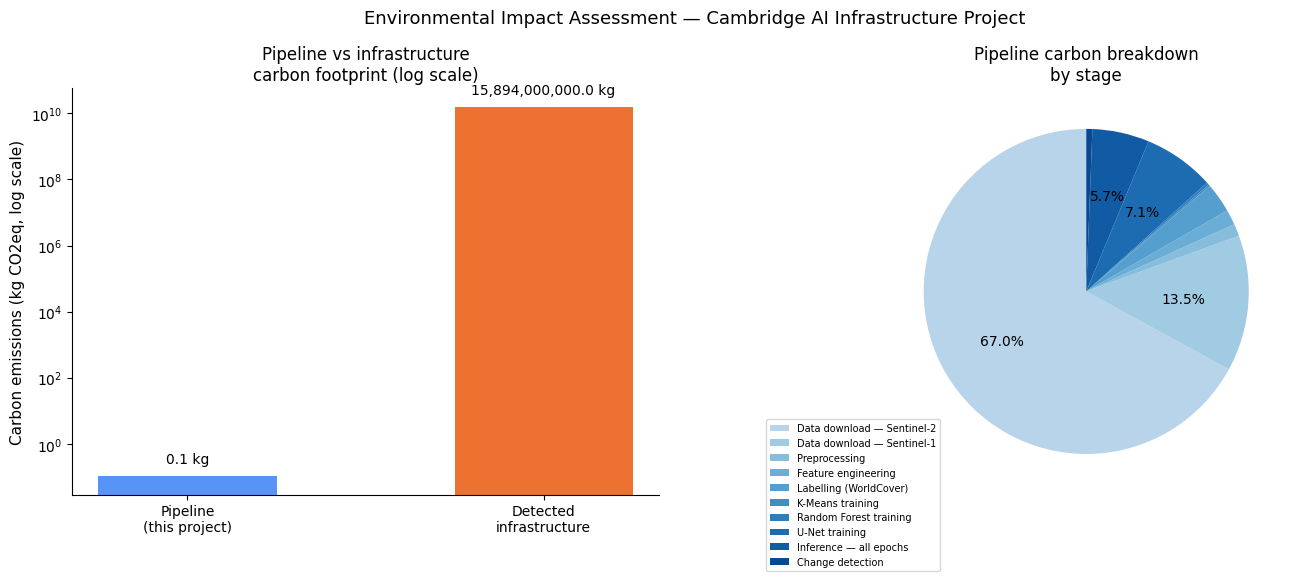

Environmental impact figure saved


In [9]:
# Visualise the comparison as a bar chart (log scale)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: log scale comparison
categories = ['Pipeline\n(this project)', 'Detected\ninfrastructure']
values_kg  = [pipeline_carbon_kg, infra_carbon_kg]
colours    = ['#3b82f6', '#ea580c']

axes[0].bar(categories, values_kg, color=colours, alpha=0.85, width=0.5)
axes[0].set_yscale('log')
axes[0].set_ylabel('Carbon emissions (kg CO2eq, log scale)', fontsize=11)
axes[0].set_title('Pipeline vs infrastructure\ncarbon footprint (log scale)', fontsize=12)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

for i, (cat, val) in enumerate(zip(categories, values_kg)):
    axes[0].text(i, val * 2, f'{val:,.1f} kg', ha='center', va='bottom', fontsize=10)

# Right: pipeline breakdown pie chart
stage_names    = [s[0] for s in stage_data]
stage_carbons  = [s[3] for s in stage_data]
colours_pie    = plt.cm.Blues(np.linspace(0.3, 0.9, len(stage_names)))

wedges, texts, autotexts = axes[1].pie(
    stage_carbons,
    labels=None,
    autopct=lambda p: f'{p:.1f}%' if p > 4 else '',
    colors=colours_pie,
    startangle=90
)
axes[1].set_title('Pipeline carbon breakdown\nby stage', fontsize=12)
axes[1].legend(wedges, stage_names, loc='lower left',
               fontsize=7, bbox_to_anchor=(-0.3, -0.2))

plt.suptitle('Environmental Impact Assessment — Cambridge AI Infrastructure Project',
             fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(outputs_path, 'environmental_impact.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Environmental impact figure saved")

Converting agricultural land to warehouse rooftops changes the surface albedo — the fraction of solar radiation reflected back to space. Lower albedo means more heat absorbed, creating a local warming signal independent of operational carbon emissions.

This biophysical impact is rarely reported in land cover change studies.


In [10]:
# Albedo values from literature
albedo_cropland   = 0.22   # typical UK arable land
albedo_warehouse  = 0.10   # dark metal warehouse rooftops (range 0.08-0.12)
albedo_change     = albedo_cropland - albedo_warehouse  # decline

# Solar radiation absorbed over converted area
# Mean annual incoming solar radiation for Cambridge: ~120 W/m²
solar_radiation   = 120    # W/m²
converted_m2      = detected_conversion_km2 * 1_000_000

# Additional energy absorbed per second due to albedo decline
extra_absorption_w = converted_m2 * solar_radiation * albedo_change

# Convert to radiative forcing in W/m² over the study area
study_area_m2     = 30_000 * 33_000  # approximate study area in m²
radiative_forcing = extra_absorption_w / study_area_m2

print("Albedo change analysis:")
print(f"  Cropland albedo:          {albedo_cropland:.2f}")
print(f"  Warehouse rooftop albedo: {albedo_warehouse:.2f}")
print(f"  Albedo decline:           {albedo_change:.2f}")
print(f"\n  Converted area: {detected_conversion_km2:.2f} km² = {converted_m2:,.0f} m²")
print(f"  Additional solar energy absorbed: {extra_absorption_w/1e9:.2f} GW")
print(f"  Local radiative forcing: +{radiative_forcing:.3f} W/m² over study area")
print(f"\n  This warming signal persists regardless of the operational")
print(f"  carbon emissions of the warehouses themselves.")
print(f"  It is a permanent biophysical change to the local energy budget.")

Albedo change analysis:
  Cropland albedo:          0.22
  Warehouse rooftop albedo: 0.10
  Albedo decline:           0.12

  Converted area: 35.32 km² = 35,320,000 m²
  Additional solar energy absorbed: 0.51 GW
  Local radiative forcing: +0.514 W/m² over study area

  This warming signal persists regardless of the operational
  carbon emissions of the warehouses themselves.
  It is a permanent biophysical change to the local energy budget.


In [11]:
# Final summary
print("=" * 65)
print("ENVIRONMENTAL IMPACT ASSESSMENT — FULL SUMMARY")
print("=" * 65)

print(f"""
PART A — PIPELINE FOOTPRINT
  Total compute energy:     {total_energy_wh/1000:.3f} kWh
  Total carbon emissions:   {total_carbon_g:.1f} gCO2eq ({pipeline_carbon_kg:.3f} kgCO2eq)
  Water consumed (cooling): {water_litres:.2f} litres
  Total data stored:        {total_data_gb:.1f} GB
  Equivalent to driving:    {pipeline_carbon_kg/0.21:.1f} km in a petrol car

PART B — DETECTED INFRASTRUCTURE FOOTPRINT
  Land converted 2019-2025: {detected_conversion_km2:.2f} km²
  Embodied carbon (mid):    {carbon_mid_tonnes:,.0f} tonnes CO2eq
  Pipeline-to-infra ratio:  1 : {ratio:,.0f}

PART C — ALBEDO RADIATIVE FORCING
  Surface albedo decline:   {albedo_change:.2f} (cropland to warehouse)
  Local radiative forcing:  +{radiative_forcing:.3f} W/m² over study area
  Additional heat absorbed: {extra_absorption_w/1e9:.2f} GW (continuous)

CONCLUSION
  The remote sensing pipeline emits {ratio:,.0f}x less carbon than the
  infrastructure it detects. Earth observation is not carbon neutral
  but is extraordinarily carbon-efficient compared to the physical
  reality it monitors. The albedo-driven warming signal — a permanent
  biophysical change — occurs regardless of operational emissions
  and is detectable only through satellite remote sensing.
""")

print("Environmental impact assessment complete.")
print("Ready for notebook 07 — visualisation.")

ENVIRONMENTAL IMPACT ASSESSMENT — FULL SUMMARY

PART A — PIPELINE FOOTPRINT
  Total compute energy:     0.454 kWh
  Total carbon emissions:   105.7 gCO2eq (0.106 kgCO2eq)
  Water consumed (cooling): 0.50 litres
  Total data stored:        10.0 GB
  Equivalent to driving:    0.5 km in a petrol car

PART B — DETECTED INFRASTRUCTURE FOOTPRINT
  Land converted 2019-2025: 35.32 km²
  Embodied carbon (mid):    15,894,000 tonnes CO2eq
  Pipeline-to-infra ratio:  1 : 150,360,042,486

PART C — ALBEDO RADIATIVE FORCING
  Surface albedo decline:   0.12 (cropland to warehouse)
  Local radiative forcing:  +0.514 W/m² over study area
  Additional heat absorbed: 0.51 GW (continuous)

CONCLUSION
  The remote sensing pipeline emits 150,360,042,486x less carbon than the
  infrastructure it detects. Earth observation is not carbon neutral
  but is extraordinarily carbon-efficient compared to the physical
  reality it monitors. The albedo-driven warming signal — a permanent
  biophysical change — occurs r